# Data Preprocessing
## CVD Fairness Dissertation — NB0

**Purpose:** Load raw data, recode gender, convert age, remove clinically implausible records, and save the cleaned dataset.

**Input:** `data/raw/cardio_train.csv`  
**Output:** `data/processed/cardio_baseline_clean.csv`

**Does NOT contain:** EDA, distributions, correlations — those are in `02_eda.ipynb`

### Dataset Description

There are 3 types of input features:

*Objective*: factual information; *Examination*: results of medical examination; *Subjective*: information given by the patient.

| Feature | Type | Notes |
|---|---|---|
| age | Objective | int (days) |
| height | Objective | int (cm) |
| weight | Objective | float (kg) |
| gender | Objective | categorical code |
| ap_hi | Examination | Systolic blood pressure |
| ap_lo | Examination | Diastolic blood pressure |
| cholesterol | Examination | 1: normal, 2: above normal, 3: well above normal |
| gluc | Examination | 1: normal, 2: above normal, 3: well above normal |
| smoke | Subjective | binary |
| alco | Subjective | binary |
| active | Subjective | binary |
| cardio | Target | binary — presence/absence of CVD diagnosis |

**Limitation:** The target variable records diagnostic outcome rather than confirmed biological disease presence. Given well-documented systematic underdiagnosis of CVD in women, a negative label cannot be assumed to reliably confirm absence of disease in female patients.

## 1. Imports and Paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

RAW_DATA   = Path("../raw/cardio_train.csv")
OUTPUT_DIR = Path("../../outputs/preprocessing")
CLEAN_OUT  = Path("../processed/cardio_baseline_clean.csv")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Raw Data and Recode Gender

Gender is recoded from the original encoding (1=female, 2=male) to a clearer binary (0=female, 1=male) used consistently throughout the project.

In [2]:
data = pd.read_csv(RAW_DATA, sep=",")
data["gender"] = data["gender"].replace({1: 0, 2: 1})  # 0=female, 1=male

assert set(data["gender"].unique()) == {0, 1}, "Unexpected gender values after recode"
assert data.isnull().sum().sum() == 0, "Null values found in raw data"

print(f"Raw dataset shape : {data.shape}")
print(f"Gender values     : {sorted(data['gender'].unique())}  (0=female, 1=male)")
print(f"Female            : {(data['gender']==0).sum():,}  ({(data['gender']==0).mean()*100:.1f}%)")
print(f"Male              : {(data['gender']==1).sum():,}  ({(data['gender']==1).mean()*100:.1f}%)")

Raw dataset shape : (70000, 13)
Gender values     : [np.int64(0), np.int64(1)]  (0=female, 1=male)
Female            : 45,530  (65.0%)
Male              : 24,470  (35.0%)


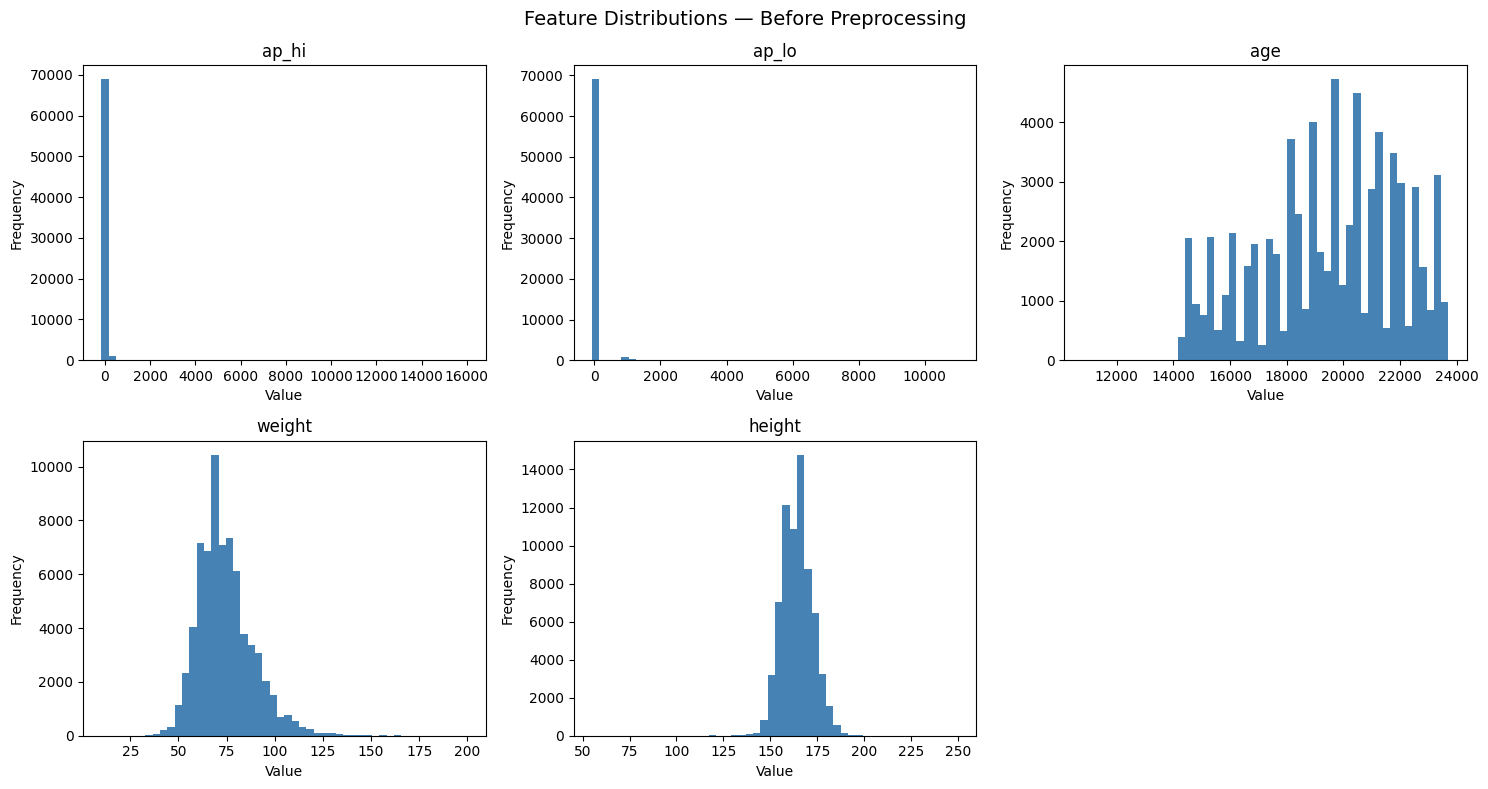

In [14]:

cols = ['ap_hi', 'ap_lo', 'age', 'weight', 'height']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), cols):
    ax.hist(data[col], bins=50, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

axes[1, 2].set_visible(False)  # hide empty sixth subplot
plt.suptitle('Feature Distributions — Before Preprocessing', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'raw_histograms_before_preprocessing.png', dpi=150)
plt.show()

## 3. Age Conversion and BMI

Age is converted from days to years. BMI is computed temporarily to help identify implausible height/weight combinations but is not retained in the final dataset.

In [13]:
data["age_years"] = data["age"] / 365.25
data["BMI"] = data["weight"] / (data["height"] / 100) ** 2

print("Age (years) summary:")
print(data["age_years"].describe().round(1))
print(f"\nBMI > 70 count : {(data['BMI'] > 70).sum()}")

Age (years) summary:
count    70000.0
mean        53.3
std          6.8
min         29.6
25%         48.4
50%         53.9
75%         58.4
max         64.9
Name: age_years, dtype: float64

BMI > 70 count : 36


## 4. Identify Implausible Values

Before applying filters, the extent of implausible values is checked to justify the exclusion thresholds used below.

In [5]:
print("Implausible blood pressure values in raw data:")
print(f"  Systolic > 250       : {(data['ap_hi'] > 250).sum()}  (range: {data[data['ap_hi']>250]['ap_hi'].min()}–{data[data['ap_hi']>250]['ap_hi'].max()})")
print(f"  Diastolic > 150      : {(data['ap_lo'] > 150).sum()}  (range: {data[data['ap_lo']>150]['ap_lo'].min()}–{data[data['ap_lo']>150]['ap_lo'].max()})")
print(f"  Systolic < 70        : {(data['ap_hi'] < 70).sum()}")
print(f"  Diastolic < 40       : {(data['ap_lo'] < 40).sum()}")
print(f"  Diastolic > Systolic : {(data['ap_lo'] > data['ap_hi']).sum()}")

Implausible blood pressure values in raw data:
  Systolic > 250       : 40  (range: 309–16020)
  Diastolic > 150      : 975  (range: 160–11000)
  Systolic < 70        : 189
  Diastolic < 40       : 59
  Diastolic > Systolic : 1234


## 5. Apply Filters

Records with clinically implausible values are removed. Each filter is logged showing how many records were kept and removed at each step.

In [6]:
def apply_filter(df, mask, name):
    before = len(df)
    df = df[mask].copy()
    after = len(df)
    print(f"{name:35s} | kept {after:6d}/{before:6d} | removed {before - after:6d}")
    return df

df = data.copy()

df = apply_filter(df, (df["age_years"] >= 30) & (df["age_years"] <= 65),  "Age 30–65 years")
df = apply_filter(df, (df["height"] >= 140)   & (df["height"] <= 220),    "Height 140–220 cm")
df = apply_filter(df, (df["weight"] >= 45)    & (df["weight"] <= 200),    "Weight 45–200 kg")
df = apply_filter(df, (df["ap_hi"] >= 70)     & (df["ap_hi"] <= 200),     "Systolic (ap_hi) 70–200")
df = apply_filter(df, (df["ap_lo"] >= 40)     & (df["ap_lo"] <= 150),     "Diastolic (ap_lo) 40–150")
df = apply_filter(df, df["ap_lo"] <= df["ap_hi"],                          "Diastolic <= Systolic")
df = apply_filter(df, df["cholesterol"].isin([1, 2, 3]),                   "Cholesterol in {1,2,3}")
df = apply_filter(df, df["gluc"].isin([1, 2, 3]),                          "Glucose in {1,2,3}")
for col in ["smoke", "alco", "active", "cardio"]:
    df = apply_filter(df, df[col].isin([0, 1]), f"{col} in {{0,1}}")

df = df.drop(columns=["id", "age", "BMI"])

print(f"\nFinal cleaned shape: {df.shape}")

Age 30–65 years                     | kept  69997/ 70000 | removed      3
Height 140–220 cm                   | kept  69844/ 69997 | removed    153
Weight 45–200 kg                    | kept  69551/ 69844 | removed    293
Systolic (ap_hi) 70–200             | kept  69266/ 69551 | removed    285
Diastolic (ap_lo) 40–150            | kept  68263/ 69266 | removed   1003
Diastolic <= Systolic               | kept  68177/ 68263 | removed     86
Cholesterol in {1,2,3}              | kept  68177/ 68177 | removed      0
Glucose in {1,2,3}                  | kept  68177/ 68177 | removed      0
smoke in {0,1}                      | kept  68177/ 68177 | removed      0
alco in {0,1}                       | kept  68177/ 68177 | removed      0
active in {0,1}                     | kept  68177/ 68177 | removed      0
cardio in {0,1}                     | kept  68177/ 68177 | removed      0

Final cleaned shape: (68177, 12)


In [7]:
# Column check
expected_cols = {"age_years", "gender", "height", "weight", "ap_hi", "ap_lo",
                 "cholesterol", "gluc", "smoke", "alco", "active", "cardio"}
assert set(df.columns) == expected_cols, f"Unexpected columns: {set(df.columns)}"

# No nulls after cleaning
assert df.isnull().sum().sum() == 0, "Nulls found in cleaned dataset"

# Expected row count
assert 67000 < len(df) < 69000, f"Unexpected row count after cleaning: {len(df)}"

print(f"All validation checks passed  ({len(df):,} rows, {df.shape[1]} columns)")

All validation checks passed  (68,177 rows, 12 columns)


## 6. Validate Cleaning Preserved Key Distributions

Checks that removing implausible records did not accidentally alter the sex ratio or class balance.

In [8]:
feature_meta = {
    "cardio":      ("Target",       "0:No CVD, 1:CVD"),
    "gender":      ("Gender (Sex)", "0=female, 1=male"),
    "cholesterol": ("Cholesterol",  "1:2:3"),
    "gluc":        ("Glucose",      "1:2:3"),
    "smoke":       ("Smoking",      "0:1"),
    "alco":        ("Alcohol",      "0:1"),
    "active":      ("Active",       "0:1"),
}

def compute_ratios(df):
    female = df[df["gender"] == 0]
    male   = df[df["gender"] == 1]
    def ratio_str(subset, col):
        cats   = sorted(subset[col].dropna().unique())
        counts = subset[col].value_counts(normalize=True).sort_index() * 100
        counts = counts.reindex(cats, fill_value=0)
        return ":".join([f"{v:.1f}" for v in counts])
    return {col: {"Total": ratio_str(df, col), "Female": ratio_str(female, col), "Male": ratio_str(male, col)}
            for col in feature_meta}

ratios_before = compute_ratios(data)
ratios_after  = compute_ratios(df)

print(f"{'Feature':<15} {'Before (Total)':<20} {'After (Total)':<20}")
print("-" * 55)
for col in feature_meta:
    print(f"{col:<15} {ratios_before[col]['Total']:<20} {ratios_after[col]['Total']:<20}")

# Key assertions
female_frac = (df["gender"] == 0).mean()
cvd_frac    = df["cardio"].mean()
assert 0.62 < female_frac < 0.68, f"Sex ratio shifted after cleaning: {female_frac:.3f}"
assert 0.48 < cvd_frac    < 0.52, f"Class balance shifted after cleaning: {cvd_frac:.3f}"
print("\nDistribution checks passed")

Feature         Before (Total)       After (Total)       
-------------------------------------------------------
cardio          50.0:50.0            50.5:49.5           
gender          65.0:35.0            65.0:35.0           
cholesterol     74.8:13.6:11.5       75.0:13.5:11.5      
gluc            85.0:7.4:7.6         85.0:7.4:7.6        
smoke           91.2:8.8             91.2:8.8            
alco            94.6:5.4             94.7:5.3            
active          19.6:80.4            19.7:80.3           

Distribution checks passed


## 7. Save Cleaned Dataset

In [9]:
df.to_csv(CLEAN_OUT, index=False)

print(f"Saved - {CLEAN_OUT}")
print(f"Final shape : {df.shape}")
print(f"Columns     : {list(df.columns)}")

Saved - ..\processed\cardio_baseline_clean.csv
Final shape : (68177, 12)
Columns     : ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years']


## 7. Distribution Table — Before and After Cleaning

In [ ]:

# 2 — then this
table_rows = [
    [
        display_name,
        cat_label,
        ratios_before[col]["Total"],
        ratios_before[col]["Female"],
        ratios_before[col]["Male"],
        ratios_after[col]["Total"],
        ratios_after[col]["Female"],
        ratios_after[col]["Male"],
    ]
    for col, (display_name, cat_label) in feature_meta.items()
]

In [1]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

THIN        = Side(style="thin", color="AAAAAA")
BORDER      = Border(left=THIN, right=THIN, top=THIN, bottom=THIN)
CENTER      = Alignment(horizontal="center", vertical="center", wrap_text=True)
LEFT        = Alignment(horizontal="left",   vertical="center", wrap_text=True)
HEADER_FONT = Font(name="Arial", bold=True, size=10)
BODY_FONT   = Font(name="Arial", size=9)

wb = Workbook()
ws = wb.active
ws.title = "Distribution Table"

# ── Row 1: top-level group headers ───────────────────────
ws.merge_cells("A1:B1")
ws.merge_cells("C1:E1")
ws.merge_cells("F1:H1")

headers = [
    ("A1", ""),
    ("C1", "Distribution Before"),
    ("F1", "Distribution After"),
]
fills = {
    "A1": "F0F0F0",
    "C1": "DCE8F5",
    "F1": "D5EAD5",
}
for cell_ref, label in headers:
    cell = ws[cell_ref]
    cell.value     = label
    cell.font      = HEADER_FONT
    cell.alignment = CENTER
    cell.fill      = PatternFill("solid", start_color=fills[cell_ref])
    cell.border    = BORDER

# ── Row 2: sub-headers ────────────────────────────────────
sub_headers = ["Feature", "Categories/Units", "Total", "Female", "Male", "Total", "Female", "Male"]
sub_fills   = ["F0F0F0", "F0F0F0", "E8EEF5", "E8EEF5", "E8EEF5", "E2F0E2", "E2F0E2", "E2F0E2"]

for col_idx, (label, fill_hex) in enumerate(zip(sub_headers, sub_fills), start=1):
    cell = ws.cell(row=2, column=col_idx, value=label)
    cell.font      = HEADER_FONT
    cell.alignment = CENTER
    cell.fill      = PatternFill("solid", start_color=fill_hex)
    cell.border    = BORDER

# ── Data rows ─────────────────────────────────────────────
for r_idx, row in enumerate(table_rows, start=3):
    fill_hex = "FFFFFF" if r_idx % 2 == 0 else "F9F9F9"
    fill     = PatternFill("solid", start_color=fill_hex)
    for c_idx, val in enumerate(row, start=1):
        cell = ws.cell(row=r_idx, column=c_idx, value=val)
        cell.font      = BODY_FONT
        cell.fill      = fill
        cell.border    = BORDER
        cell.alignment = LEFT if c_idx <= 2 else CENTER

# ── Column widths ─────────────────────────────────────────
for col_idx, width in enumerate([20, 25, 12, 12, 12, 12, 12, 12], start=1):
    ws.column_dimensions[get_column_letter(col_idx)].width = width
ws.row_dimensions[1].height = 18
ws.row_dimensions[2].height = 18

wb.save(OUTPUT_DIR / "distribution_table.xlsx")
print("Saved -> distribution_table.xlsx")

NameError: name 'table_rows' is not defined